# 01 -Dev Environment

## Install Bottom-up

(Each Subsequent Layer depends on the one before it)

4. AI/ML Libraries - PyTorch, JAX, transformers, etc.
3. Language Runtimes - Python 3.11+, Node 20+, Rust, Julia
2. Package Managers - uv, pnpm, cargo, juliaup
1. System Foundation - OS, shell, git, editor, GPU drivers

Python Virtual Environment

Activate

`source .venv/bin/activate`

## UV Venv Test

In [1]:
import torch

In [2]:
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: False


In [3]:
print(f"MPS available: {torch.backends.mps.is_available()}")

MPS available: True


In [4]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

CUDA not available


# 02 Git and Collaboration

# 03 GPU Setup and Cloud

Google Colab Notebook

https://colab.research.google.com/drive/17lxdgnPggXjhZE2raN-TkqoTKLl62S_d#scrollTo=nfYf8Sc6r00k

Used G4 GPU runtime:
- GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
- CUDA version: 13


# 04 APIs and Keys

## Anthropic's Python SDK

In [1]:
import os
import anthropic

In [3]:

client = anthropic.Anthropic()

In [4]:
MODEL = os.environ.get("LLM_MODEL", "claude-sonnet-5")

In [5]:
MODEL

'claude-sonnet-5'

In [6]:
response = client.messages.create(
    model=MODEL,
    max_tokens=256,
    messages=[
        {
            "role": "user",
            "content": "What is a neural network in one sentence?"
        }
    ]
)

In [8]:
print(response.content[0].text)

A neural network is a computational model inspired by the human brain, consisting of interconnected layers of nodes ("neurons") that learn to recognize patterns and make predictions by adjusting the strength of connections between them based on training data.


## Anthropic's Typescript SDK

1. In the project root run the following
```bash
npm install @anthropic-ai/sdk
npm install --save-dev tsx
```

2. Then to run the first api call script `learner/mark/phase-00/experiments/first_api_calls/anthropic/typescript/first_api_call.ts` run the following

```bash
node --env-file=.env --import tsx learner/mark/phase-00/experiments/first_api_calls/anthropic/typescript/first_api_call.ts
```
or use tsx directly

```bash
npx tsx --env-file=.env \
  learner/mark/phase-00/experiments/first_api_calls/anthropic/typescript/first_api_call.ts
```

- `--env-file=.env` - makes ANTHROPIC_API_KEY and an optional LLM_MODEL available via process.env. It has been supported by Node since v20.6.0, so it works with the course’s Node 22 environment. 



## Anthropic's API - Raw HTTP 

In [1]:
import os
import urllib.request
import json

In [13]:
url = "https://api.anthropic.com/v1/messages"

headers = {
    "Content-Type": "application/json",
    "x-api-key": os.environ.get("ANTHROPIC_API_KEY"),
    "anthropic-version": "2023-06-01",
}

question = "What are the 3 most popular travel destinations"

body = json.dumps({
    "model": os.environ.get("LLM_MODEL", "claude-sonnet-5"),
    "max_tokens": 256,
    "messages": [
        {
            "role": "user",
            "content": question
        }
    ]
}).encode()

In [15]:
req = urllib.request.Request(url, data=body, headers=headers, method="POST")

In [16]:
with urllib.request.urlopen(req) as resp:
    result = json.loads(resp.read())
    print(result["content"][0]["text"])

# Popular Travel Destinations

The "most popular" can vary depending on the source and metric (visitor numbers, search trends, etc.), but based on international tourist arrivals, these are consistently among the top destinations:

1. **France** 🇫🇷 - Paris and the French Riviera draw millions with iconic landmarks like the Eiffel Tower, Louvre, and stunning countryside

2. **Spain** 🇪🇸 - Known for vibrant cities like Barcelona and Madrid, beautiful beaches, rich history, and excellent food culture

3. **United States** 🇺🇸 - Offers diverse experiences from NYC and LA to national parks like Yellowstone and the Grand Canyon

**Other frequently top-ranked destinations include:**


# 05 Jupyter Notebooks

### When to Use Notebooks

The rule: explore in notebooks, ship in scripts.

A common workflow in AI:

1. Explore data in a notebook
2. Prototype your model in the notebook
3. Once it works, move the code to .py files
4. Import those .py files back into the notebook for further experiments

| Use notebooks for |	Use scripts for |
| ----------------- | ----------------- |
| Exploring a dataset |	Training pipelines |
| Prototyping a model |	Reusable utilities |
| Visualizing results |	Anything with if __name__ |
| Explaining your work |	Code that runs on a schedule |
| Quick experiments |	Production code |
| Course exercises |	Packages and libraries |

### Common Traps

**Out-of-order execution.** You run cell 5, then cell 2, then cell 7. The notebook works on your machine but breaks when someone runs it top to bottom. Fix: Kernel > Restart & Run All before sharing.

**Hidden state.** You delete a cell but the variable it created is still in memory. The notebook looks clean but depends on a ghost cell. Fix: Restart the kernel regularly.

**Memory leaks.** Loading a 4GB dataset, training a model, loading another dataset. Nothing gets freed. Fix: del variable_name and gc.collect(), or restart the kernel.

### Command Mode

| Key |	Action |
| --- | ------ |
| Shift+Enter |	Run cell, move to next |
| A |	Insert cell above |
| B |	Insert cell below |
| DD |	Delete cell |
| M |	Convert to markdown |
| Y |	Convert to code |
| Z |	Undo cell operation |
| Ctrl+Shift+H |	Show all shortcuts |

### Edit Mode

| Key |	Action |
| --- | ------ |
| Tab |	Autocomplete |
| Shift+Tab |	Show function signature |
| Ctrl+/ |	Toggle comment |

### Numpy

In [17]:
import numpy as np

data = np.random.randn(1000)

In [18]:
data

array([-6.10070260e-02, -2.46755022e-01, -9.48277074e-01,  9.00364495e-02,
        7.13210336e-01, -6.87648943e-02,  8.13749746e-01, -1.75533847e-01,
       -1.32445432e-01,  9.40760999e-01,  9.23943469e-02, -8.84096229e-01,
        5.14020664e-02, -2.05065239e-01, -7.88907550e-01,  8.95330021e-01,
       -9.70389935e-03, -7.02983932e-01,  1.94083606e+00,  1.72562346e+00,
        9.53163008e-01,  9.25661357e-01, -5.70475182e-01,  2.17916401e-01,
        5.01172473e-01, -9.38039484e-01, -1.75981942e+00, -2.59628079e-01,
       -4.16505081e-01, -1.34243374e+00, -5.85221167e-01, -3.48187184e-01,
       -8.84080174e-01,  4.26362700e-02,  2.18092782e+00, -8.20682842e-01,
        1.08493891e+00, -3.07844948e-01, -4.98257086e-01, -8.64696480e-01,
       -1.01919944e+00, -1.38736040e-01,  9.02135879e-01, -1.31890598e+00,
        1.23846399e+00,  1.63103017e+00, -3.18000100e-01, -7.82223398e-01,
        1.00453535e+00, -4.68271854e-01,  8.37688261e-01, -1.63923169e+00,
       -9.45392101e-01, -

In [25]:
data.mean()

np.float64(-0.030320035263223723)

In [26]:
data.std()

np.float64(0.9728653141511655)

### Jupyter Notebook Magic Commands

% is Line Magic

In [29]:
%timeit np.random.randn(1000)

13.1 μs ± 189 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


%% is Cell Magic

In [51]:
%%time

import numpy as np
from tensorflow import keras


rng = np.random.default_rng(seed=42)

X_train = rng.uniform(low=-10, high=10, size=(1000, 1))


X_train[0][0]
y_train = 3 * X_train - 2 + rng.normal(loc=0, scale=1, size=(1000, 1))
y_train[0][0]
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))
])

model.compile(optimizer="sgd", loss="mse")


history = model.fit(X_train, y_train, epochs=10, verbose=0)

CPU times: user 329 ms, sys: 57.9 ms, total: 387 ms
Wall time: 315 ms


`%%time` measures the whole cell’s execution time, including the ten training epochs. Run it a few times before comparing timings: the first run may be slower because TensorFlow is importing, initializing, and preparing internal code.

In [52]:
# Inspect what the Linear Regression Model learned

weight, bias = model.layers[0].get_weights()

print("weight", weight.item())

print("bias", bias.item())

print("final loss:", history.history["loss"][-1])

weight 3.041609525680542
bias -2.074424982070923
final loss: 1.0463488101959229


### Matplotlib

In [54]:
%matplotlib inline

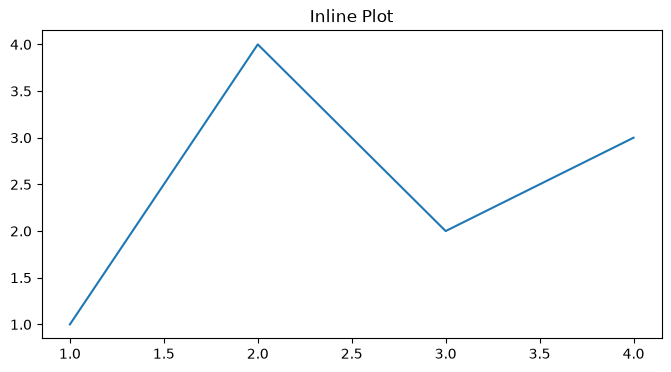

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])
plt.title("Inline Plot")
plt.show()

### Display Rich Output Inline

In [56]:
import pandas as pd

df = pd.DataFrame({
    "model": ["Linear", "Random Forest", "Neural Net"],
    "accuracy": [0.72, 0.89, 0.94],
    "training_time": [0.1, 2.3, 45.6]
})
df


,model,accuracy,training_time
0,Linear,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Net,0.94,45.6


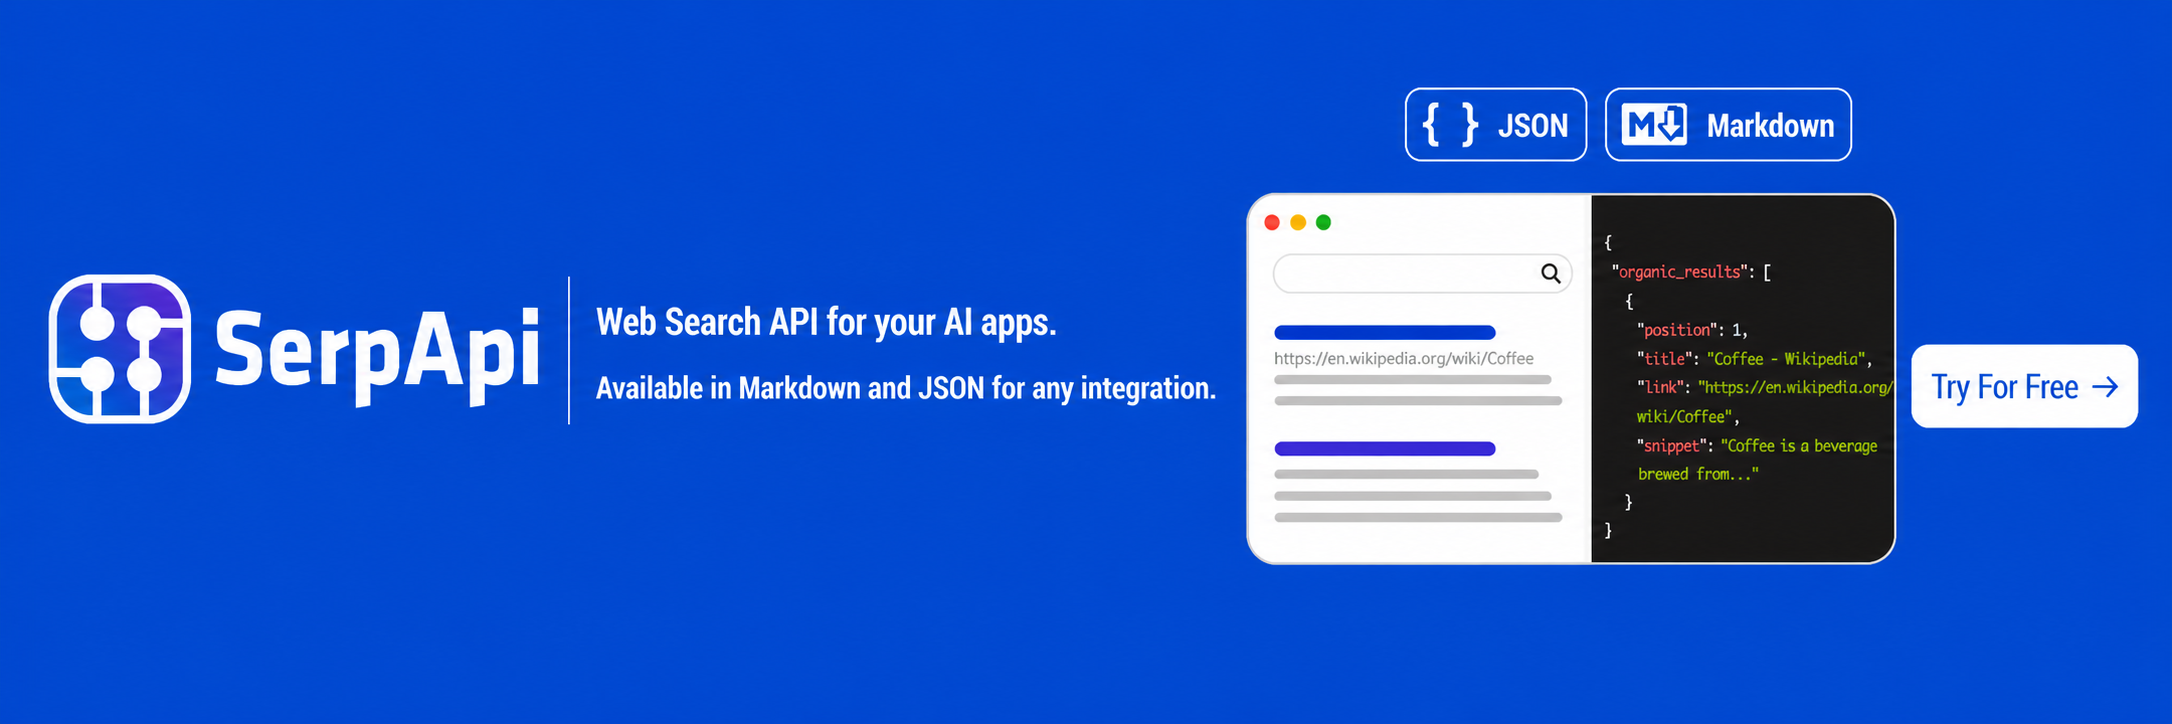

In [59]:
from IPython.display import Image, display

display(Image(filename="../../../assets/sponsors/serpapi-banner.png"))